In [2]:
!pip install transformers datasets nltk accelerate torch

In [3]:
import os

os.makedirs("lab09/data", exist_ok=True)
os.makedirs("lab09/models", exist_ok=True)
os.makedirs("lab09/results", exist_ok=True)

In [4]:
from datasets import load_dataset

dataset = load_dataset("biglam/gutenberg-poetry-corpus", split="train")

print(f"Dataset încărcat: {len(dataset)} versuri")

for i in range(0, 11):
  print(dataset[i])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/903 [00:00<?, ?B/s]

data/train-00000-of-00001-fa9fb9e1f16eed(…):   0%|          | 0.00/91.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3085117 [00:00<?, ? examples/s]

Dataset încărcat: 3085117 versuri
{'line': 'The Song of Hiawatha is based on the legends and stories of', 'gutenberg_id': 19}
{'line': 'many North American Indian tribes, but especially those of the', 'gutenberg_id': 19}
{'line': 'Ojibway Indians of northern Michigan, Wisconsin, and Minnesota.', 'gutenberg_id': 19}
{'line': 'They were collected by Henry Rowe Schoolcraft, the reknowned', 'gutenberg_id': 19}
{'line': 'Schoolcraft married Jane, O-bah-bahm-wawa-ge-zhe-go-qua (The', 'gutenberg_id': 19}
{'line': 'fur trader, and O-shau-gus-coday-way-qua (The Woman of the Green', 'gutenberg_id': 19}
{'line': 'Prairie), who was a daughter of Waub-o-jeeg (The White Fisher),', 'gutenberg_id': 19}
{'line': 'who was Chief of the Ojibway tribe at La Pointe, Wisconsin.', 'gutenberg_id': 19}
{'line': 'Jane and her mother are credited with having researched,', 'gutenberg_id': 19}
{'line': 'authenticated, and compiled much of the material Schoolcraft', 'gutenberg_id': 19}
{'line': 'included in his Algi

In [16]:
# Grupăm versurile în strofe (4 versuri per strofă)
def creaza_strofa(dataset, versuri_per_strofa=4):
    strofe = []

    current_poem_lines = []

    for item in dataset:

        line = item['line'] if 'line' in item else item['text']

        line = line.strip()

        if line:
            current_poem_lines.append(line)

            if len(current_poem_lines) == versuri_per_strofa:
                strofe.append(current_poem_lines.copy())

                current_poem_lines = []

    return strofe

In [17]:
strofe = creaza_strofa(dataset)
print(f"Total strofe create: {len(strofe)}")
print(f"\nExemplu strofă:\n")
for line in strofe[0]:
    print(f"  {line}")

Total strofe create: 771279

Exemplu strofă:

  The Song of Hiawatha is based on the legends and stories of
  many North American Indian tribes, but especially those of the
  Ojibway Indians of northern Michigan, Wisconsin, and Minnesota.
  They were collected by Henry Rowe Schoolcraft, the reknowned


# Cerinta a

In [5]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
# GPT2LMHeadModel = modelul GPT-2 pentru generare de text (LM = Language Model)
# GPT2Tokenizer = tokenizatorul asociat modelului GPT-2

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Folosim: {device}")

# Descarcam vocabularul si regulile de tokenizare
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained("gpt2")

model = model.to(device)

print("Model încărcat cu succes!")
print(f"Parametri model: {sum(p.numel() for p in model.parameters()):,}")

Folosim: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model încărcat cu succes!
Parametri model: 124,439,808


In [19]:
def genereaza_vers(prompt, model, tokenizer, device, **kwargs):
    """
    Genereaza versuri pornind de la un prompt, care reprezinta primul vers la strofei.

    prompt: string cu primul vers
    model: modelul GPT-2 încărcat
    tokenizer: tokenizatorul asociat
    device: "cuda" sau "cpu"
    **kwargs: parametrii de generare (temperature, top_k, etc.)
    """

    # Incepem cu tokenizarea prompt-ului si toate cuvintele din text se transforma in tokeni, iar ulterior in id-uri numerice
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():

        output = model.generate(
            input_ids,
            attention_mask=attention_mask,

            max_new_tokens=kwargs.get("max_new_tokens", 80), # numarul maxim de tokeni pe care vrem sa ii identifice modelul

            temperature=kwargs.get("temperature", 0.9),
            # Controlează "creativitatea":
            # < 1.0 = mai conservator, mai predictibil
            # > 1.0 = mai creativ, mai haotic
            # = 1.0 = distribuția originală a modelului

            top_k=kwargs.get("top_k", 50), # La fiecare pas, alege doar din primele 50 cuvinte posibile, eliminând cuvintele foarte improbabile

            top_p=kwargs.get("top_p", 0.92),

            repetition_penalty=kwargs.get("repetition_penalty", 1.2),
            # Penalizeaza repetarea acelorasi cuvinte
            # 1.0 = fara penalizare, 1.5 = penalizare puternica

            do_sample=kwargs.get("do_sample", True),
            # True = sampling (aleator, creativ)
            # False = greedy (alege mereu cel mai probabil cuvant)

            num_beams=kwargs.get("num_beams", 1),
            # Beam search: exploreaza mai multe cai simultan
            # 1 = dezactivat (incompatibil cu do_sample=True)

            pad_token_id=tokenizer.eos_token_id
            # Spunem modelului ce token sa foloseasca pentru padding
        )

    # Decodificarea textului
    generated_text = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    generated_only = generated_text[len(prompt):].strip()

    return generated_only

In [12]:
test_prompt = strofe[0][0]

print(f"Prompt: {test_prompt}")
print(f"\nGenerat:\n{genereaza_vers(test_prompt, model, tokenizer, device)}")

test_prompt = strofe[0][1]

print(f"\nPrompt: {test_prompt}")
print(f"\nGenerat:\n{genereaza_vers(test_prompt, model, tokenizer, device)}")

Prompt: The Song of Hiawatha is based on the legends and stories of

Generat:
Chinese warrior men from antiquity. Although it was originally named after Han dynasty's king, Yue Bing Shi (薬子 手服) had changed his name to "Yue Long" because he couldn't bear being called a hiu-po or hai in this country since birth so when all those who were born before him died young people started calling themselves Yungsou

Prompt: many North American Indian tribes, but especially those of the

Generat:
Navajo people.
I am also a member for some years now of an association that has sponsored and funded initiatives on behalf in this area as well. We have been doing what we can to assist Native Americans who may otherwise face discrimination."
The event was held at Stony Creek Center & Casino Building with several hundred participants from three different communities including: Alaska Wazoo Apache Tribe; Siski


In [18]:
def analiza_parametrilor(prompt, model, tokenizer, device):

    configs = [
        {
            "name": "Conservative (temp=0.3)",
            "temperature": 0.3,  # temperatura mica => text predictibil, putin creativ
            "top_k": 40,
            "top_p": 0.85,
            "repetition_penalty": 1.1
        },
        {
            "name": "Balanced (temp=0.7)",
            "temperature": 0.7,  # temperatura medie => echilibru creativitate / coerenta
            "top_k": 50,
            "top_p": 0.92,
            "repetition_penalty": 1.2
        },
        {
            "name": "Creative (temp=1.2)",
            "temperature": 1.2,  # temperatura mare => foarte creativ, poate fi incoerent
            "top_k": 100,
            "top_p": 0.95,
            "repetition_penalty": 1.0
        },
        {
            "name": "Greedy (no sampling)",
            "do_sample": False,   # Fara sampling = mereu cel mai probabil cuvant
            "num_beams": 3,
            "temperature": 1.0
        }
    ]

    results = []

    print(f"Prompt: '{prompt}'\n")
    print("=" * 60)

    for config in configs:

        name = config.pop("name")

        generated = genereaza_vers(prompt, model, tokenizer, device, **config)

        print(f"\n Config: {name}")
        print(f" Text generat:\n{generated}")
        print("-" * 60)

        results.append({
            "config": name,
            "generated": generated,
            "params": config
        })

    return results

In [19]:
first_line = strofe[0][0]
results = analiza_parametrilor(first_line, model, tokenizer, device)

Prompt: 'The Song of Hiawatha is based on the legends and stories of'


 Config: Conservative (temp=0.3)
 Text generat:
a young girl who was born in an orphanage. She has been raised by her mother, but she does not know how to become strong enough for life without being taught about love or kindness."
A few years ago I read this book from my friend's library: "It tells the story behind many famous childrens' tales that have come out over the last several decades - including those written between
------------------------------------------------------------

 Config: Balanced (temp=0.7)
 Text generat:
a number that have been told. The songs were written in ancient times when there was no land to call home, but now it seems clear they are actually from an alternate world where humans live together as part people called kaiju (Kangaroos) or Kaguya warriors who fight with all their might for survival against monsters such about to strike down civilization!
I've also read one
---------------

In [20]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculeaza_bleu(reference_lines, generated_text):

    reference_tokens = [
        nltk.word_tokenize(line.lower()) # transformam in litere mici deoarece BLEU e case-sensitive
        for line in reference_lines
    ]
    # Rezultat: [['word1', 'word2'], ['word3', 'word4'], ...]

    generated_tokens = nltk.word_tokenize(generated_text.lower())

    smoother = SmoothingFunction().method1

    bleu_1 = sentence_bleu(reference_tokens, generated_tokens,
                           weights=(1, 0, 0, 0),
                           smoothing_function=smoother)

    bleu_2 = sentence_bleu(reference_tokens, generated_tokens,
                           weights=(0.5, 0.5, 0, 0),
                           smoothing_function=smoother)

    bleu_4 = sentence_bleu(reference_tokens, generated_tokens,
                           weights=(0.25, 0.25, 0.25, 0.25),
                           smoothing_function=smoother)

    return {
        "bleu_1": round(bleu_1, 4),
        "bleu_2": round(bleu_2, 4),
        "bleu_4": round(bleu_4, 4)
    }

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [25]:
strofa_originala = strofe[0]

prompt = strofa_originala[0]

reference = strofa_originala[1:]

generated = genereaza_vers(prompt, model, tokenizer, device)
scores = calculeaza_bleu(reference, generated)

print(f"Prompt: {prompt}")
print(f"\nOriginal: {' | '.join(reference)}")
print(f"\nGenerat: {generated}")
print(f"\nBLEU scores: {scores}")

Prompt: The Song of Hiawatha is based on the legends and stories of

Original: many North American Indian tribes, but especially those of the | Ojibway Indians of northern Michigan, Wisconsin, and Minnesota. | They were collected by Henry Rowe Schoolcraft, the reknowned

Generat: many different tribes that were brought into existence by Naga people, including Bona Yula. The story also relates to Dhamma meaning "the song," which means coming back from a distant past (or future). When these songs are played in this way it becomes very difficult for us to understand them even though they have been sung more than any other time since Aeneas' day at least

BLEU scores: {'bleu_1': 0.12, 'bleu_2': 0.0127, 'bleu_4': 0.0042}


In [26]:
def evaluare_cerinta(stanzas, model, tokenizer, device, n_samples=20):

    import random

    random.seed(42)

    sample_stanzas = random.sample(stanzas, min(n_samples, len(stanzas)))

    all_scores = []

    for i, stanza in enumerate(sample_stanzas):

        prompt = stanza[0]
        reference = stanza[1:]

        generated = genereaza_vers(
            prompt, model, tokenizer, device,
            temperature=0.7, top_k=50, top_p=0.92
        )

        scores = calculeaza_bleu(reference, generated)
        all_scores.append(scores)

        if i % 5 == 0:
            print(f"Progres: {i+1}/{n_samples}")

    avg_bleu_1 = sum(s["bleu_1"] for s in all_scores) / len(all_scores)

    avg_bleu_2 = sum(s["bleu_2"] for s in all_scores) / len(all_scores)
    avg_bleu_4 = sum(s["bleu_4"] for s in all_scores) / len(all_scores)

    print("\n" + "="*50)
    print("RAPORT EVALUARE - Model Pre-antrenat (GPT-2)")
    print("="*50)
    print(f"Număr strofe evaluate: {n_samples}")
    print(f"BLEU-1 mediu: {avg_bleu_1:.4f}")
    print(f"BLEU-2 mediu: {avg_bleu_2:.4f}")
    print(f"BLEU-4 mediu: {avg_bleu_4:.4f}")

    return all_scores

scores_pretrained = evaluare_cerinta(strofe, model, tokenizer, device)

Progres: 1/20
Progres: 6/20
Progres: 11/20
Progres: 16/20

RAPORT EVALUARE - Model Pre-antrenat (GPT-2)
Număr strofe evaluate: 20
BLEU-1 mediu: 0.0828
BLEU-2 mediu: 0.0168
BLEU-4 mediu: 0.0052


# Cerinta b

In [7]:
# Pregatirea datelor pentru antrenare
def pregatire_date(dataset, max_poems=5000):
    """
    Transforma dataset-ul de versuri intr-un singur text continuu
    pe care modelul îl va "citi" în timpul antrenarii.
    """

    poems_text = []

    strofa = []

    count = 0

    for item in dataset:

        if count >= max_poems:
            break

        line = item.get('line', item.get('text', '')).strip()

        if line:
            strofa.append(line)

            if len(strofa) == 4:

                text_strofa = "\n".join(strofa)

                poems_text.append(text_strofa)

                strofa = []
                count += 1

    full_corpus = "\n<|endoftext|>\n".join(poems_text)

    print(f"Corpus pregătit: {count} strofe")
    print(f"Total caractere: {len(full_corpus):,}")
    print(f"\nExemplu (primele 200 caractere):\n{full_corpus[:200]}")

    return full_corpus

In [8]:
corpus_text = pregatire_date(dataset)

Corpus pregătit: 5000 strofe
Total caractere: 879,260

Exemplu (primele 200 caractere):
The Song of Hiawatha is based on the legends and stories of
many North American Indian tribes, but especially those of the
Ojibway Indians of northern Michigan, Wisconsin, and Minnesota.
They were col


In [9]:
corpus_path = "lab09/data/poetry_corpus.txt"

with open(corpus_path, "w", encoding="utf-8") as f:
    f.write(corpus_text)

print(f"Corpus salvat în: {corpus_path}")

Corpus salvat în: lab09/data/poetry_corpus.txt


In [10]:
from torch.utils.data import Dataset, DataLoader

class PoetryDataset(Dataset):

    def __init__(self, corpus_text, tokenizer, max_length=128):

        self.tokenizer = tokenizer
        self.max_length = max_length


        tokenized = tokenizer(
            corpus_text,
            return_tensors="pt",
            truncation=False,
            padding=False
        )

        self.all_token_ids = tokenized["input_ids"][0]

        print(f"Total tokeni în corpus: {len(self.all_token_ids):,}")

        self.n_sequences = len(self.all_token_ids) // max_length

        print(f"Secvențe de antrenare create: {self.n_sequences:,}")

    def __len__(self):

        return self.n_sequences

    def __getitem__(self, idx):
        start = idx * self.max_length

        end = start + self.max_length

        input_ids = self.all_token_ids[start:end]

        labels = input_ids.clone()

        return {
            "input_ids": input_ids,
            "labels": labels
        }

poetry_dataset = PoetryDataset(
    corpus_text,
    tokenizer,
    max_length=128
)

Token indices sequence length is longer than the specified maximum sequence length for this model (235709 > 1024). Running this sequence through the model will result in indexing errors


Total tokeni în corpus: 235,709
Secvențe de antrenare create: 1,841


In [11]:
from torch.utils.data import random_split

total_size = len(poetry_dataset)

train_size = int(0.8 * total_size)

val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    poetry_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {train_size} secvențe")
print(f"Validation: {val_size} secvențe")

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print(f"\nBatch-uri train: {len(train_loader)}")
print(f"Batch-uri validare: {len(val_loader)}")

Train: 1472 secvențe
Validation: 369 secvențe

Batch-uri train: 184
Batch-uri validare: 47


In [12]:
import torch
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import time

def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    """
    Antrenează modelul pentru O singură epocă.

    model: modelul GPT-2
    loader: DataLoader cu datele de antrenare
    optimizer: algoritmul de optimizare (AdamW)
    scheduler: programatorul learning rate-ului
    device: "cuda" sau "cpu"
    epoch: numărul epocii curente (pentru logging)
    """

    model.train()

    total_loss = 0.0

    start_time = time.time()

    for batch_idx, batch in enumerate(loader):

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            avg_loss_so_far = total_loss / (batch_idx + 1)
            elapsed = time.time() - start_time
            print(f"  Epoch {epoch} | Batch {batch_idx+1}/{len(loader)} | "
                  f"Loss: {avg_loss_so_far:.4f} | Timp: {elapsed:.1f}s")

    avg_loss = total_loss / len(loader)
    return avg_loss


def validate_epoch(model, loader, device):
    """
    Evaluează modelul pe datele de validare.
    NU actualizăm parametrii — doar calculăm loss-ul.
    """

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, labels=labels)
            total_loss += outputs.loss.item()

    avg_loss = total_loss / len(loader)

    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    return avg_loss, perplexity

In [13]:
def full_training_pipeline(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=3,
    learning_rate=5e-5
):
    """
    Pipeline complet de antrenare.

    num_epochs: de câte ori parcurgem întregul dataset
    learning_rate: cât de mari sunt pașii de update (5e-5 = 0.00005)
    """

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.01
    )

    total_steps = len(train_loader) * num_epochs

    warmup_steps = total_steps // 10

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    print(f"Total pași antrenare: {total_steps}")
    print(f"Pași warmup: {warmup_steps}")
    print(f"Începem antrenarea pe {device}...\n")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_perplexity": []
    }

    best_val_loss = float('inf')

    for epoch in range(1, num_epochs + 1):

        print(f"\n{'='*50}")
        print(f"EPOCA {epoch}/{num_epochs}")
        print(f"{'='*50}")

        # Antrenare
        train_loss = train_epoch(
            model, train_loader, optimizer, scheduler, device, epoch
        )

        # Validare
        val_loss, val_perplexity = validate_epoch(model, val_loader, device)

        # Salvam in istoric
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_perplexity"].append(val_perplexity)

        print(f"\n Epoch {epoch} Summary:")
        print(f"   Train Loss:      {train_loss:.4f}")
        print(f"   Val Loss:        {val_loss:.4f}")
        print(f"   Val Perplexity:  {val_perplexity:.2f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            save_path = "lab09/models/gpt2_poetry_finetuned"
            model.save_pretrained(save_path)

            tokenizer.save_pretrained(save_path)

            print(f" Model salvat (val_loss îmbunătățit: {best_val_loss:.4f})")

    return history

ft_model = GPT2LMHeadModel.from_pretrained("gpt2")
ft_model = ft_model.to(device)

history = full_training_pipeline(
    ft_model,
    train_loader,
    val_loader,
    device,
    num_epochs=3,
    learning_rate=5e-5
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total pași antrenare: 552
Pași warmup: 55
Începem antrenarea pe cuda...


EPOCA 1/3


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Epoch 1 | Batch 50/184 | Loss: 5.1358 | Timp: 15.8s
  Epoch 1 | Batch 100/184 | Loss: 4.7918 | Timp: 31.5s
  Epoch 1 | Batch 150/184 | Loss: 4.6407 | Timp: 47.8s

 Epoch 1 Summary:
   Train Loss:      4.5687
   Val Loss:        4.0652
   Val Perplexity:  58.28


...

 Model salvat (val_loss îmbunătățit: 4.0652)

EPOCA 2/3
  Epoch 2 | Batch 50/184 | Loss: 4.0362 | Timp: 16.4s
  Epoch 2 | Batch 100/184 | Loss: 4.0393 | Timp: 32.7s
  Epoch 2 | Batch 150/184 | Loss: 4.0445 | Timp: 48.9s

 Epoch 2 Summary:
   Train Loss:      4.0264
   Val Loss:        3.9499
   Val Perplexity:  51.93


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model salvat (val_loss îmbunătățit: 3.9499)

EPOCA 3/3
  Epoch 3 | Batch 50/184 | Loss: 3.8661 | Timp: 16.2s
  Epoch 3 | Batch 100/184 | Loss: 3.8958 | Timp: 32.8s
  Epoch 3 | Batch 150/184 | Loss: 3.8677 | Timp: 49.2s

 Epoch 3 Summary:
   Train Loss:      3.8695
   Val Loss:        3.9223
   Val Perplexity:  50.52


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model salvat (val_loss îmbunătățit: 3.9223)


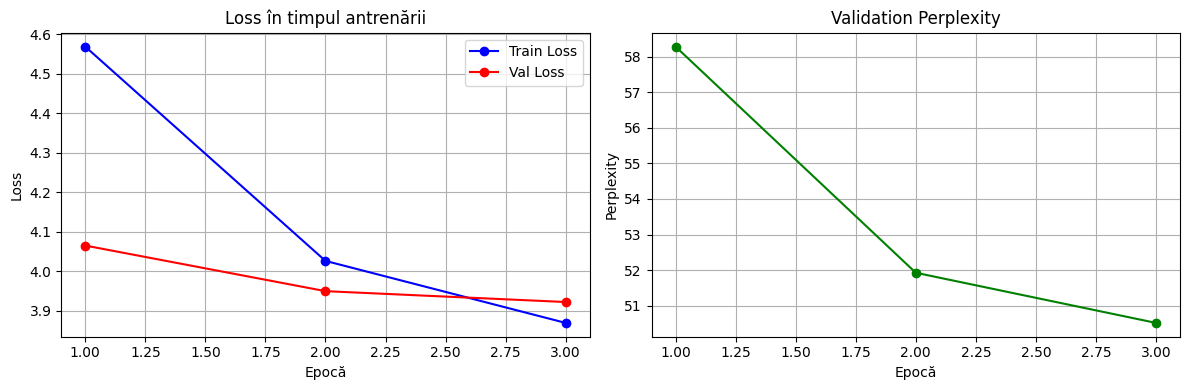

In [14]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Afișează graficele de loss și perplexity din antrenare.
    Util pentru a vedea dacă modelul a conversat sau a dat overfit.
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"],
                 'b-o', label="Train Loss")

    axes[0].plot(epochs, history["val_loss"],
                 'r-o', label="Val Loss")

    axes[0].set_title("Loss în timpul antrenării")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["val_perplexity"], 'g-o')
    axes[1].set_title("Validation Perplexity")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Perplexity")
    axes[1].grid(True)

    plt.tight_layout()

    plt.savefig("lab09/results/training_history.png", dpi=150)

    plt.show()

plot_training_history(history)

In [21]:
def compare_models(stanzas, pretrained_model, finetuned_model,
                   tokenizer, device, n_samples=10):
    """
    Compară modelul pre-antrenat cu cel fine-tuned.
    Calculează BLEU pentru ambele și afișează exemple side-by-side.
    Aceasta e baza pentru cerința c.1.
    """

    import random
    random.seed(123)

    samples = random.sample(stanzas, min(n_samples, len(stanzas)))

    pretrained_bleus = []
    finetuned_bleus  = []

    for i, stanza in enumerate(samples):
        prompt    = stanza[0]
        reference = stanza[1:]

        gen_params = dict(temperature=0.8, top_k=50, top_p=0.92,
                          repetition_penalty=1.2)

        text_pretrained = genereaza_vers(
            prompt, pretrained_model, tokenizer, device, **gen_params
        )
        text_finetuned  = genereaza_vers(
            prompt, finetuned_model,  tokenizer, device, **gen_params
        )

        score_pre = calculeaza_bleu(reference, text_pretrained)
        score_ft  = calculeaza_bleu(reference, text_finetuned)

        pretrained_bleus.append(score_pre["bleu_4"])
        finetuned_bleus.append(score_ft["bleu_4"])

        if i < 3:
            print(f"\n{'='*60}")
            print(f"PROMPT:      {prompt}")
            print(f"ORIGINAL:    {' | '.join(reference)}")
            print(f"\n GPT-2 pre-antrenat (BLEU-4: {score_pre['bleu_4']:.4f}):")
            print(f"  {text_pretrained[:150]}")
            print(f"\n GPT-2 fine-tuned    (BLEU-4: {score_ft['bleu_4']:.4f}):")
            print(f"  {text_finetuned[:150]}")

    avg_pre = sum(pretrained_bleus) / len(pretrained_bleus)
    avg_ft  = sum(finetuned_bleus)  / len(finetuned_bleus)

    print(f"\n{'='*60}")
    print(f"REZULTATE FINALE:")
    print(f"  GPT-2 pre-antrenat — BLEU-4 mediu: {avg_pre:.4f}")
    print(f"  GPT-2 fine-tuned   — BLEU-4 mediu: {avg_ft:.4f}")
    print(f"  Îmbunătățire:  {((avg_ft - avg_pre) / avg_pre * 100):+.1f}%")

    return pretrained_bleus, finetuned_bleus

finetuned_model = GPT2LMHeadModel.from_pretrained(
    "lab09/models/gpt2_poetry_finetuned"
)
finetuned_model = finetuned_model.to(device)

pre_scores, ft_scores = compare_models(
    strofe, model, finetuned_model, tokenizer, device
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


PROMPT:      And, that they might not freeze alone in bed,
ORIGINAL:    Chosen young lovers in their husbands' stead. | "With others' children filled the Grecian crew | Their houses found, and by consent was past

 GPT-2 pre-antrenat (BLEU-4: 0.0037):
  or turn off the lights.
"Why would I?" asked Gilderich when she first went to see him this morning at his house on a weekend evening after two years o

 GPT-2 fine-tuned    (BLEU-4: 0.0163):
  So close the doorway and shut it off.  He drew his knife with one hand;

PROMPT:      For I have ways to look on worlds afar.
ORIGINAL:    And deeper yet--twelve million leagues of twilight | Divide mine empire even from Saturn's ken. | Is there a world whose light is not as my light,

 GPT-2 pre-antrenat (BLEU-4: 0.0042):
  They will be there, as well. And so it goes with my life," he says.


  He lives in the woods behind a house that is also haunted by an old man who ha

 GPT-2 fine-tuned    (BLEU-4: 0.0184):
  And they, and the way of Life; t

# Cerinta c

In [22]:
# Diferentele de calitate intre textele generate cu cele doua tipuri de LLM-uri

def qualitative_analysis(stanzas, pretrained_model, finetuned_model,
                          tokenizer, device):
    """
    Analiză calitativă detaliată între cele două modele.
    Măsurăm nu doar BLEU, ci și:
    - diversitatea vocabularului
    - lungimea medie a versurilor generate
    - repetitivitatea
    """
    import random
    from collections import Counter

    random.seed(42)
    samples = random.sample(stanzas, 20)

    def compute_metrics(generated_text):
        """
        Calculează metrici de calitate pentru un text generat.
        """
        words = generated_text.lower().split()

        if len(words) == 0:
            return {"vocab_diversity": 0, "avg_word_len": 0,
                    "repetition_rate": 0, "total_words": 0}

        unique_words = set(words)

        vocab_diversity = len(unique_words) / len(words)

        avg_word_len = sum(len(w) for w in words) / len(words)

        word_counts = Counter(words)

        most_common_count = word_counts.most_common(1)[0][1]

        repetition_rate = most_common_count / len(words)

        return {
            "vocab_diversity": round(vocab_diversity, 3),
            "avg_word_len":    round(avg_word_len, 3),
            "repetition_rate": round(repetition_rate, 3),
            "total_words":     len(words)
        }

    metrics_pre = []
    metrics_ft  = []

    for stanza in samples:
        prompt = stanza[0]
        gen_params = dict(temperature=0.8, top_k=50,
                          top_p=0.92, repetition_penalty=1.2)

        text_pre = genereaza_vers(prompt, pretrained_model,
                                  tokenizer, device, **gen_params)
        text_ft  = genereaza_vers(prompt, finetuned_model,
                                  tokenizer, device, **gen_params)

        metrics_pre.append(compute_metrics(text_pre))
        metrics_ft.append(compute_metrics(text_ft))

    def average_metrics(metrics_list):
        """
        Primește o listă de dicționare cu metrici și returnează mediile.
        """
        keys = metrics_list[0].keys()

        return {
            key: round(sum(m[key] for m in metrics_list) / len(metrics_list), 3)
            for key in keys
        }

    avg_pre = average_metrics(metrics_pre)
    avg_ft  = average_metrics(metrics_ft)

    print("\n" + "="*55)
    print("ANALIZĂ CALITATIVĂ — Pre-antrenat vs Fine-tuned")
    print("="*55)
    print(f"{'Metrică':<25} {'Pre-antrenat':>12} {'Fine-tuned':>12}")
    print("-"*55)

    for key in avg_pre:
        print(f"{key:<25} {avg_pre[key]:>12} {avg_ft[key]:>12}")

    print("="*55)
    print("\nInterpretare:")
    print("- vocab_diversity: mai mare = mai variat (mai bun pentru poezie)")
    print("- avg_word_len:    mai mare = cuvinte mai complexe/poetice")
    print("- repetition_rate: mai mic  = mai puțină repetiție (mai bun)")

qualitative_analysis(strofe, model, finetuned_model, tokenizer, device)
# Vocabular diversity este mai mare la modelul pre-antrenat (0.972) decât la modelul fine-tuned (0.589). Deși la prima vedere acest lucru ar putea sugera că modelul
# pre-antrenat este mai bun, în contextul poeziei această valoare ridicată indică adesea un limbaj mai aleator și mai puțin structurat.
# Modelul fine-tuned are un vocabular mai restrâns, dar mai concentrat pe domeniul poeziei, ceea ce reflectă o adaptare mai bună la stilul dorit.


ANALIZĂ CALITATIVĂ — Pre-antrenat vs Fine-tuned
Metrică                   Pre-antrenat   Fine-tuned
-------------------------------------------------------
vocab_diversity                  0.972        0.589
avg_word_len                     4.187        2.625
repetition_rate                  0.044        0.109
total_words                      58.15         10.1

Interpretare:
- vocab_diversity: mai mare = mai variat (mai bun pentru poezie)
- avg_word_len:    mai mare = cuvinte mai complexe/poetice
- repetition_rate: mai mic  = mai puțină repetiție (mai bun)


In [23]:
# Versuri in engleza clasice pentru test

english_prompts = [
    "Shall I compare thee to a summer's day",
    "I wandered lonely as a cloud",
    "Do not go gentle into that good night",
    "Two roads diverged in a yellow wood",
    "Because I could not stop for Death"
]

def test_english_prompts(prompts, pretrained_model, finetuned_model,
                          tokenizer, device):
    """
    Testează ambele modele pe versuri englezești clasice.
    Așteptare: ambele modele ar trebui să performeze bine
    fiindcă GPT-2 e antrenat pe engleză, iar corpusul nostru
    de fine-tuning e tot în engleză.
    """

    print("="*60)
    print("c.2 — TESTE CU VERSURI ÎN ENGLEZĂ")
    print("="*60)

    for prompt in prompts:
        print(f"\n Prompt: '{prompt}'")
        print("-"*50)
        tokens = tokenizer.tokenize(prompt)
        print(f"   Tokeni ({len(tokens)}): {tokens}")

        gen_pre = genereaza_vers(prompt, pretrained_model, tokenizer, device,
                                  temperature=0.8, top_k=50, top_p=0.92)

        gen_ft  = genereaza_vers(prompt, finetuned_model, tokenizer, device,
                                  temperature=0.8, top_k=50, top_p=0.92)

        print(f"\nPre-antrenat:\n   {gen_pre[:200]}")
        print(f"\nFine-tuned:\n   {gen_ft[:200]}")

        div_pre = len(set(gen_pre.split())) / max(len(gen_pre.split()), 1)
        div_ft  = len(set(gen_ft.split()))  / max(len(gen_ft.split()),  1)
        print(f"\n   Diversitate vocabular — Pre: {div_pre:.2f} | FT: {div_ft:.2f}")

test_english_prompts(english_prompts, model, finetuned_model,
                     tokenizer, device)

# GPT-2 pre-antrenat generează texte mai lungi și mai elaborate, dar cu un stil predominant narativ, uneori lipsit de legătură cu tema poetică inițială.
# Modelul fine-tuned tinde să producă output mai scurt, uneori chiar incomplet (ex: doar virgule sau fragmente), ceea ce sugerează o sensibilitate mai mare la datele
# de antrenare și o tendință de „colaps” pe tipare repetitive.

c.2 — TESTE CU VERSURI ÎN ENGLEZĂ

 Prompt: 'Shall I compare thee to a summer's day'
--------------------------------------------------
   Tokeni (10): ['Sh', 'all', 'ĠI', 'Ġcompare', 'Ġthee', 'Ġto', 'Ġa', 'Ġsummer', "'s", 'Ġday']

Pre-antrenat:
   , O man!
I shall be with you from the morning till sunset. Wherefore thou shalt make thy appearance; and if there is no light among us then let it shine in my eyes: but after that time what will we se

Fine-tuned:
   ,

   Diversitate vocabular — Pre: 1.00 | FT: 1.00

 Prompt: 'I wandered lonely as a cloud'
--------------------------------------------------
   Tokeni (6): ['I', 'Ġwandered', 'Ġlonely', 'Ġas', 'Ġa', 'Ġcloud']

Pre-antrenat:
   of dust settled and became restless again. The wind was rough, the sun shone softly above my head like one who is about to faint from thirst but I could not help looking down at it with all those eyes

Fine-tuned:
   ,

   Diversitate vocabular — Pre: 1.00 | FT: 1.00

 Prompt: 'Do not go gentle into that

In [24]:
romanian_prompts = [
    "La steaua care-a răsărit",
    "Eu nu strivesc corola de minuni a lumii",
    "Cu mâinile mele creai o lume",
    "De atâtea nopți aud plouând",
    "Câmpul verde se întinde lin"
]

def test_romanian_prompts(prompts, pretrained_model, finetuned_model,
                           tokenizer, device):
    """
    Testează ambele modele pe versuri românești.

    Ce ne așteptăm să observăm:
    1. Tokenizarea va fi proastă — română e "necunoscută" pentru GPT-2
    2. Modelul va tinde să continue în engleză
    3. Fine-tuned-ul va face același lucru (corpusul era în engleză)
    4. Caracterele speciale (ș,ț,â,î,ă) pot fi tokenizate ciudat
    """

    print("="*60)
    print("c.3 — TESTE CU VERSURI ÎN ROMÂNĂ")
    print("="*60)

    for prompt in prompts:
        print(f"\n Prompt: '{prompt}'")

        tokens = tokenizer.tokenize(prompt)
        token_ids = tokenizer.encode(prompt)

        print(f"   Tokeni ({len(tokens)}): {tokens}")
        print(f"   Token IDs: {token_ids}")

        chars_per_token = len(prompt) / len(tokens)
        print(f"   Caractere/token: {chars_per_token:.1f} "
              f"(engleză tipică: ~4.0)")

        gen_pre = genereaza_vers(prompt, pretrained_model, tokenizer, device,
                                  temperature=0.8, top_k=50, top_p=0.92)
        gen_ft  = genereaza_vers(prompt, finetuned_model, tokenizer, device,
                                  temperature=0.8, top_k=50, top_p=0.92)

        print(f"\nPre-antrenat:\n   {gen_pre[:200]}")
        print(f"\nFine-tuned:\n   {gen_ft[:200]}")

        english_markers = {"the", "and", "of", "in", "a", "to", "is",
                            "that", "with", "for", "on", "are", "was"}

        words_pre = set(gen_pre.lower().split())

        english_ratio_pre = len(words_pre & english_markers) / max(len(english_markers), 1)

        words_ft  = set(gen_ft.lower().split())
        english_ratio_ft  = len(words_ft  & english_markers) / max(len(english_markers), 1)

        print(f"\n  Detecție schimbare limbă:")
        print(f"   Pre-antrenat — cuvinte englezești: {english_ratio_pre:.0%}")
        print(f"   Fine-tuned   — cuvinte englezești: {english_ratio_ft:.0%}")

test_romanian_prompts(romanian_prompts, model, finetuned_model,
                      tokenizer, device)

# Fine-tuning-ul pe poezie îmbunătățește stilul, dar NU rezolvă problema limbii.
# GPT-2 nu generalizează bine la română fără antrenare specifică.

c.3 — TESTE CU VERSURI ÎN ROMÂNĂ

 Prompt: 'La steaua care-a răsărit'
   Tokeni (14): ['La', 'Ġste', 'au', 'a', 'Ġcare', '-', 'a', 'Ġr', 'Ä', 'ĥ', 's', 'Ä', 'ĥ', 'rit']
   Token IDs: [14772, 2876, 559, 64, 1337, 12, 64, 374, 128, 225, 82, 128, 225, 799]
   Caractere/token: 1.7 (engleză tipică: ~4.0)

Pre-antrenat:
   (bruse lím) kélle.
: The place where you can find some free and affordable meals, or of course the cafe will not let that happen but we really appreciate all your suggestions!  We love to bring delici

Fine-tuned:
   ,
In his canoe ute o'er the lake; and to him fell.

  Detecție schimbare limbă:
   Pre-antrenat — cuvinte englezești: 46%
   Fine-tuned   — cuvinte englezești: 31%

 Prompt: 'Eu nu strivesc corola de minuni a lumii'
   Tokeni (13): ['E', 'u', 'Ġnu', 'Ġstrives', 'c', 'Ġcor', 'ola', 'Ġde', 'Ġmin', 'uni', 'Ġa', 'Ġlum', 'ii']
   Token IDs: [36, 84, 14364, 37873, 66, 1162, 5708, 390, 949, 35657, 257, 46390, 4178]
   Caractere/token: 3.0 (engleză tipică: ~4.0)

Pre-

In [26]:
def analyze_crosslingual_effect(romanian_prompts, finetuned_model,
                                  tokenizer, device):
    """
    c.4: Ce se întâmplă când prompt-ul e în română dar
    modelul a fost fine-tunat pe engleză?

    Experimentăm cu mai mulți parametri ca să vedem
    dacă putem "forța" modelul să rămână în română.
    """

    print("="*60)
    print("c.4 — ROMÂNĂ + MODEL ANTRENAT PE ENGLEZĂ")
    print("="*60)

    configs = [
        {
            "name": "Standard",
            "temperature": 0.8,
            "top_k": 50,
            "top_p": 0.92,
            "repetition_penalty": 1.2
        },
        {
            "name": "Temperatură mică (mai conservator)",
            "temperature": 0.3,
            "top_k": 20,
            "top_p": 0.85,
            "repetition_penalty": 1.1
        },
        {
            "name": "Temperatură mare (mai haotic)",
            "temperature": 1.3,
            "top_k": 200,
            "top_p": 0.98,
            "repetition_penalty": 1.0
        },
        {
            "name": "Greedy search",
            "do_sample": False,
            "num_beams": 3,
            "temperature": 1.0,
            "repetition_penalty": 1.3
        }
    ]

    prompt = romanian_prompts[0]
    print(f"\nPrompt: '{prompt}'\n")

    results_summary = []

    for cfg in configs:
        name = cfg.pop("name")

        generated = genereaza_vers(prompt, finetuned_model,
                                    tokenizer, device, **cfg)

        ro_chars = sum(1 for c in generated if c in "ășțîâĂȘȚÎÂ")

        en_words = {"the","and","of","in","a","to","is","it","that","with"}
        en_count = sum(1 for w in generated.lower().split() if w in en_words)

        print(f" {name}")
        print(f"   Output: {generated[:150]}")
        print(f"   Diacritice românești în output: {ro_chars}")
        print(f"   Cuvinte englezești detectate: {en_count}")
        print()

        results_summary.append({
            "config": name,
            "ro_chars": ro_chars,
            "en_words": en_count,
            "text": generated
        })

    print(" CONCLUZIE c.4:")
    print("   Modelul fine-tunat pe engleză tinde să:")
    print("   1. Ignore diacriticele românești din prompt")
    print("   2. Comute la engleză după primele cuvinte")
    print("   3. Genereze text incoerent când temperatura e mare")
    print("   → Soluție reală: fine-tuning pe corpus ROMÂNESC")

    return results_summary

results_c4 = analyze_crosslingual_effect(romanian_prompts, finetuned_model,
                                          tokenizer, device)

c.4 — ROMÂNĂ + MODEL ANTRENAT PE ENGLEZĂ

Prompt: 'La steaua care-a răsărit'



The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


 Standard
   Output: ,
Hither to his owne state of innocence;  But now the Angelic Light with all speed retires.
   Diacritice românești în output: 0
   Cuvinte englezești detectate: 4

 Temperatură mică (mai conservator)
   Output: ,
   Diacritice românești în output: 0
   Cuvinte englezești detectate: 0

 Temperatură mare (mai haotic)
   Output: ,
   Diacritice românești în output: 0
   Cuvinte englezești detectate: 0

 Greedy search
   Output: ,
   Diacritice românești în output: 0
   Cuvinte englezești detectate: 0

 CONCLUZIE c.4:
   Modelul fine-tunat pe engleză tinde să:
   1. Ignore diacriticele românești din prompt
   2. Comute la engleză după primele cuvinte
   3. Genereze text incoerent când temperatura e mare
   → Soluție reală: fine-tuning pe corpus ROMÂNESC


In [27]:
def generate_pastel_style(model, tokenizer, device):
    """
    c.5: Generăm versuri în stil pastel — cu accent pe
    frumusețea naturii.

    Strategii implementate:
    1. Prompt engineering (cel mai simplu)
    2. Prefix forțat cu imagini din natură
    3. Post-procesare pentru selecția celui mai 'natural' output
    """

    print("="*60)
    print("c.5 — GENERARE STIL PASTEL")
    print("="*60)

    pastel_prompts = [
        "The golden fields stretch far and wide",
        "Beneath the ancient oak tree stands",
        "The morning dew on petals rests",
        "When autumn paints the hills in gold",
        "Câmpul înflorit în zori de zi"
    ]

    nature_vocabulary = {
        "meadow", "field", "valley", "hill", "mountain", "river",
        "stream", "lake", "forest", "wood", "tree", "flower",
        "sunrise", "sunset", "dawn", "dusk", "twilight", "moonlight",
        "sunlight", "shadow", "mist", "fog", "rain", "snow", "wind",
        "rose", "lily", "oak", "willow", "bird", "butterfly", "bee",
        "petal", "leaf", "branch", "grass", "moss", "fern",
        "golden", "silver", "pale", "soft", "gentle", "quiet", "still"
    }

    def nature_score(text):
        """
        Calculează cât de 'natural/pastoral' e un text.
        Proxy simplu: proporția cuvintelor din vocabularul naturii.
        """
        words = set(text.lower().split())

        overlap = words & nature_vocabulary

        score = len(overlap) / max(len(words), 1)
        return score, overlap


    def generate_best_pastel(prompt, model, tokenizer, device,
                              n_candidates=5):
        """
        Generează n_candidates texte și îl returnează pe cel cu
        cel mai mare nature_score.
        """

        candidates = []

        for _ in range(n_candidates):

            text = genereaza_vers(
                prompt, model, tokenizer, device,
                temperature=0.9,
                top_k=60,
                top_p=0.93,
                repetition_penalty=1.15,
                max_new_tokens=100
            )
            score, words = nature_score(text)
            candidates.append((score, text, words))

        candidates.sort(key=lambda x: x[0], reverse=True)

        return candidates[0]


    nature_prefix = (
        "In this pastoral poem about nature's beauty, "
        "fields, flowers, and gentle light: "
    )

    print("\n STRATEGIA 1: Prompt simplu")
    print("-"*40)
    for prompt in pastel_prompts[:3]:
        score, best_text, nature_words = generate_best_pastel(
            prompt, model, tokenizer, device, n_candidates=5
        )
        print(f"\nPrompt: '{prompt}'")
        print(f"Text:   {best_text[:180]}")
        print(f"Nature score: {score:.3f} | Cuvinte naturale: {nature_words}")

    print("\n\n STRATEGIA 2: Prefix cu context de natură")
    print("-"*40)
    for prompt in pastel_prompts[:3]:
        prefixed_prompt = nature_prefix + prompt

        score, best_text, nature_words = generate_best_pastel(
            prefixed_prompt, model, tokenizer, device, n_candidates=5
        )
        display_text = best_text.replace(nature_prefix, "").strip()

        print(f"\nPrompt (cu prefix): '{prompt}'")
        print(f"Text:   {display_text[:180]}")
        print(f"Nature score: {score:.3f} | Cuvinte naturale: {nature_words}")

generate_pastel_style(model, tokenizer, device)

# Modelul nu poate menține un stil semantic (pastel), ci doar generează text probabilistic care uneori conține cuvinte din natură.

c.5 — GENERARE STIL PASTEL

 STRATEGIA 1: Prompt simplu
----------------------------------------

Prompt: 'The golden fields stretch far and wide'
Text:   , reaching down to the ground beneath him. They're lush in their fragrant aroma and rich with green leaves soothed by a scent of fresh grasses that are filled with mossy tawnies (s
Nature score: 0.027 | Cuvinte naturale: {'flower', 'tree'}

Prompt: 'Beneath the ancient oak tree stands'
Text:   a young child that looks to be in his early twenties. A few minutes later, as they look up and down at each other on what appears to be an unfamiliar sky bridge or across another g
Nature score: 0.034 | Cuvinte naturale: {'still', 'river', 'stream'}

Prompt: 'The morning dew on petals rests'
Text:   ;
. . . for thy sake, that thou mayest be made thine own master."

 I am told his face grew so pale as to look like an infant's head and the rest of him looked quite black--as did 
Nature score: 0.012 | Cuvinte naturale: {'pale'}


 STRATEGIA 2: Pre

In [32]:
def save_best_poem(model, tokenizer, device):
    """
    Generăm mai multe poezii complete, le evaluăm și o salvăm
    pe cea mai reușită — gata de trimis unui prieten!
    """

    candidate_prompts = [
        "The sun sets slow on golden hills",
        "Beneath the silver willow tree",
        "When morning mist fills quiet vales",
        "The meadow dreams in twilight's hush"
    ]

    nature_vocabulary = {
        "meadow","field","valley","hill","river","forest","flower",
        "sunrise","sunset","moonlight","sunlight","shadow","mist",
        "rose","lily","petal","leaf","golden","silver","gentle","soft"
    }

    best_poem = None
    best_score = -1

    print("Generăm și evaluăm poezii candidate...\n")

    for prompt in candidate_prompts:

        full_poem_lines = [prompt]

        current_context = prompt

        for verse_num in range(3):
            new_verse = genereaza_vers(
                current_context, model, tokenizer, device,
                temperature=0.85,
                top_k=50,
                top_p=0.92,
                repetition_penalty=1.2,
                max_new_tokens=25
            )

            first_line = new_verse.split('\n')[0].strip()

            if first_line:
                full_poem_lines.append(first_line)
                current_context = first_line

        poem_text = "\n".join(full_poem_lines)
        words = set(poem_text.lower().split())
        overlap = words & nature_vocabulary
        score = len(overlap) / max(len(words), 1)

        print(f" Scor {score:.3f}:")
        for line in full_poem_lines:
            print(f"   {line}")
        print()

        if score > best_score:
            best_score = score
            best_poem  = full_poem_lines

    # ---- FORMATĂM ȘI SALVĂM POEZIA ----
    poem_output = f"""
{chr(10).join(best_poem)}
Generată cu GPT-2 | Nature score: {best_score:.3f}
"""

    print("="*45)
    print(" CEA MAI REUȘITĂ POEZIE:")
    print(poem_output)

    # Salvăm pe disc
    with open("lab09/results/best_poem.txt", "w", encoding="utf-8") as f:
        f.write(poem_output)

    return best_poem

best_poem = save_best_poem(model, tokenizer, device)

Generăm și evaluăm poezii candidate...

 Scor 0.030:
   The sun sets slow on golden hills
   , and the clouds fill in. The air is warm enough for us to eat our food at night! A beautiful day of
   peace!"
   And the crowd grew even larger.

 Scor 0.019:
   Beneath the silver willow tree
   , you can see it in action.
   The one thing that I was surprised by here is how often people talk about what they know as 'the big picture'.
   There's lots of things you need to be a part out there, but when it comes down all these smaller and bigger questions

 Scor 0.021:
   When morning mist fills quiet vales
   .
   5-11] to be included in the list of items for which there is a reasonable likelihood that such an item will not
   qualify as qualifying "diverse services", or (iii) shall, by written notification provided at all times and during those notifications

 Scor 0.023:
   The meadow dreams in twilight's hush
   -hut have a deep meaning, but it can also be said that all my best efforts to 